# Music Diffusion Transformer

## Dataset

The [Song Describer Dataset (SDD)](https://zenodo.org/records/10072001) is a multimodal music-language dataset designed for tasks such as music captioning, text-to-music generation, and music-language retrieval. It contains approximately 1,100 human-written natural language captions paired with 706 permissively licensed music recordings, covering a wide range of musical styles, instruments, moods, and production characteristics. The dataset was introduced by researchers from institutions including Queen Mary University of London and Universitat Pompeu Fabra as a public benchmark for evaluating music-and-language models. Unlike many proprietary music datasets, SDD emphasizes open accessibility and standardized evaluation for cross-modal learning research. It is particularly suitable for training and benchmarking Transformer-, diffusion-, and CLAP-based architectures for text-conditioned music generation and retrieval tasks

In [1]:
from torch.utils.data import Dataset
import pandas as pd
import numpy as np
import librosa
import torch
import os


class AudioDataset(Dataset):
    def __init__(self, csv_path="./dataset/song_describer.csv", audio_dir="./dataset/audio/"):
        self.df = pd.read_csv(csv_path)
        self.audio_dir = audio_dir
        self.SAMPLE_RATE = 22050
        self.N_MELS = 80
        self.N_FFT = 1024
        self.HOP_LENGTH = 256
        self.WIN_LENGTH = 1024
        self.max_len = self.SAMPLE_RATE * 10
        self.generate_file_map()

    def __len__(self):
        return len(self.df)

    def generate_file_map(self):
        self.file_map = {}

        for root, dirs, files in os.walk(self.audio_dir):
            for f in files:
                if f.endswith(".mp3"):
                    track_id = f.split(".")[0]
                    self.file_map[track_id] = os.path.join(root, f)
    
    def load_audio(self, path, target_sr=22050):
        wav, sr = librosa.load(path, sr=target_sr, mono=True)

        if len(wav) > self.max_len:
            wav = wav[:self.max_len]
        else:
            wav = np.pad(wav, (0, self.max_len - len(wav)))
        return wav

    def audio_to_mel(self, audio_path):
        wav = self.load_audio(audio_path, self.SAMPLE_RATE)
    
        mel = librosa.feature.melspectrogram(
            y=wav,
            sr=self.SAMPLE_RATE,
            n_fft=self.N_FFT,
            hop_length=self.HOP_LENGTH,
            win_length=self.WIN_LENGTH,
            n_mels=self.N_MELS,
            fmin=0,
            fmax=8000,
            power=1.0
        )
    
        mel = np.log(np.maximum(mel, 1e-5))
    
        # roughly normalize for diffusion
        mel = np.clip(mel, -11.5, 2.0)
        mel_norm = (mel + 11.5) / 13.5 * 2 - 1
    
        return torch.tensor(mel_norm, dtype=torch.float32).unsqueeze(0)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        caption = row["caption"]
        track_id = str(row["track_id"])

        mel_spectrum = self.audio_to_mel(self.file_map[track_id])
        return mel_spectrum, caption


def denorm_for_bigvgan(mel_norm):
    mel = mel_norm.clamp(-1, 1)
    mel = (mel + 1) / 2 * 13.5 - 11.5
    return mel

D:\Softwares\minconda3\envs\llm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


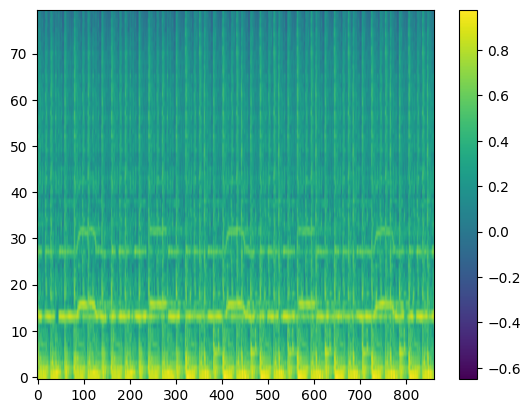

In [2]:
import matplotlib.pyplot as plt

audio_dataset = AudioDataset()

mel_np = audio_dataset[0][0].squeeze(0).detach().cpu().numpy()
plt.imshow(mel_np, origin="lower", aspect="auto")
plt.colorbar()

## Model Architectures

### CLAP Text Encoder

The CLAP Text Encoder is used to convert a natural language music prompt into a fixed-dimensional conditioning embedding. It uses a pretrained CLAP model, which has learned an aligned representation space between text and audio. Given an input caption, the processor first tokenizes the text and creates the attention mask, then the CLAP text encoder extracts a semantic text feature. This feature is L2-normalized and passed through a projection layer so that its dimension matches the diffusion model’s conditioning input. During training, the CLAP model is frozen, and only the downstream diffusion model learns how to use the text embedding to guide mel-spectrogram generation.

In [3]:
from transformers import ClapModel, ClapProcessor
import torch
import torch.nn as nn

class CLAPTextEncoder(nn.Module):
    def __init__(self, model_name="laion/clap-htsat-fused", out_dim=512):
        super().__init__()
        self.processor = ClapProcessor.from_pretrained(model_name)
        self.clap = ClapModel.from_pretrained(model_name)

        for p in self.clap.parameters():
            p.requires_grad = False

        self.proj = nn.Linear(768, out_dim)

    def forward(self, prompts):
        device = next(self.clap.parameters()).device

        inputs = self.processor(
            text=prompts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        with torch.no_grad():
            outputs = self.clap.text_model(**inputs)
            token_emb = outputs.last_hidden_state

        token_emb = self.proj(token_emb)

        return token_emb

D:\Softwares\minconda3\envs\llm\Lib\site-packages\transformers\integrations\sonicmoe.py:99: FutureWarning: torch._dynamo.allow_in_graph is deprecated and will be removed in a future version. Use torch._dynamo.nonstrict_trace instead.
  @torch._dynamo.allow_in_graph
D:\Softwares\minconda3\envs\llm\Lib\site-packages\torch\compiler\__init__.py:148: FutureWarning: torch._dynamo.allow_in_graph is deprecated and will be removed in a future version. Use torch._dynamo.nonstrict_trace instead.
  return torch._dynamo.allow_in_graph(fn)


### Diffusion Model

In [5]:
class NoiseScheduler:
    def __init__(self, num_steps=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.num_steps = num_steps
        self.device = device

        self.betas = torch.linspace(beta_start, beta_end, num_steps).to(device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, x0, noise, t):
        alpha_bar = self.alpha_bars[t].view(-1, 1, 1, 1)
        return torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * noise

    @torch.no_grad()
    def step(self, x_t, pred_noise, t):
        beta_t = self.betas[t]
        alpha_t = self.alphas[t]
        alpha_bar_t = self.alpha_bars[t]

        beta_t = beta_t.view(-1, 1, 1, 1)
        alpha_t = alpha_t.view(-1, 1, 1, 1)
        alpha_bar_t = alpha_bar_t.view(-1, 1, 1, 1)

        mean = (1 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / torch.sqrt(1 - alpha_bar_t)) * pred_noise
        )

        noise = torch.randn_like(x_t)

        mask = (t > 0).float().view(-1, 1, 1, 1)

        return mean + mask * torch.sqrt(beta_t) * noise


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)

    def forward(self, x, temb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        h = h + self.time_proj(temb).view(-1, h.shape[1], 1, 1)

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + self.skip(x)


class CrossAttentionBlock(nn.Module):
    def __init__(self, dim, cond_dim=512, num_heads=1):
        super().__init__()

        self.norm = nn.LayerNorm(dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.cond_proj = nn.Linear(cond_dim, dim)

    def forward(self, x, cond):
        # x: [B, C, H, W]
        # cond: [B, text_len, cond_dim]

        B, C, H, W = x.shape

        x_seq = x.flatten(2).transpose(1, 2)   # [B, H*W, C]
        x_norm = self.norm(x_seq)

        cond = self.cond_proj(cond)            # [B, text_len, C]

        attn_out, _ = self.attn(
            query=x_norm,
            key=cond,
            value=cond
        )

        x_seq = x_seq + attn_out

        return x_seq.transpose(1, 2).view(B, C, H, W)


class CrossAttentionBlock(nn.Module):
    def __init__(self, dim, cond_dim=512, num_heads=4):
        super().__init__()

        self.norm = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True
        )

        self.cond_proj = nn.Linear(cond_dim, dim)

    def forward(self, x, cond):
        # x: [B, C, H, W]
        # cond: [B, text_len, cond_dim]

        B, C, H, W = x.shape

        x_seq = x.flatten(2).transpose(1, 2)   # [B, H*W, C]
        x_norm = self.norm(x_seq)

        cond = self.cond_proj(cond)            # [B, text_len, C]

        attn_out, _ = self.attn(
            query=x_norm,
            key=cond,
            value=cond
        )

        x_seq = x_seq + attn_out

        x = x_seq.transpose(1, 2).view(B, C, H, W)

        return x


class CrossAttentionUNet(nn.Module):
    def __init__(self, cond_dim=512, time_dim=128, num_heads=1):
        super().__init__()

        self.time_embed = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # Encoder
        self.down1 = ResBlock(1, 64, time_dim)
        self.pool1 = nn.Conv2d(64, 64, 4, stride=2, padding=1)

        self.down2 = ResBlock(64, 128, time_dim)
        self.pool2 = nn.Conv2d(128, 128, 4, stride=2, padding=1)

        self.down3 = ResBlock(128, 256, time_dim)
        self.pool3 = nn.Conv2d(256, 256, 4, stride=2, padding=1)

        # Bottleneck
        self.mid1 = ResBlock(256, 256, time_dim)
        self.cross_attn = CrossAttentionBlock(
            dim=256,
            cond_dim=cond_dim,
            num_heads=num_heads
        )
        self.mid2 = ResBlock(256, 256, time_dim)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 256, 4, stride=2, padding=1)
        self.dec3 = ResBlock(256 + 256, 128, time_dim)

        self.up2 = nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1)
        self.dec2 = ResBlock(128 + 128, 64, time_dim)

        self.up1 = nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1)
        self.dec1 = ResBlock(64 + 64, 64, time_dim)

        self.out = nn.Conv2d(64, 1, 3, padding=1)

    def forward(self, x, t, cond_tokens):
        # x: [B, 1, 80, T]
        # t: [B]
        # cond_tokens: [B, text_len, 512]

        original_h, original_w = x.shape[2], x.shape[3]

        t = t.float().unsqueeze(-1) / 1000.0
        temb = self.time_embed(t)

        # Encoder
        h1 = self.down1(x, temb)       # [B, 64, H, W]
        p1 = self.pool1(h1)

        h2 = self.down2(p1, temb)      # [B, 128, H/2, W/2]
        p2 = self.pool2(h2)

        h3 = self.down3(p2, temb)      # [B, 256, H/4, W/4]
        p3 = self.pool3(h3)

        # Bottleneck
        h = self.mid1(p3, temb)
        h = self.cross_attn(h, cond_tokens)
        h = self.mid2(h, temb)

        # Decoder + skip connections
        h = self.up3(h)
        h = self.match_size(h, h3)
        h = torch.cat([h, h3], dim=1)
        h = self.dec3(h, temb)

        h = self.up2(h)
        h = self.match_size(h, h2)
        h = torch.cat([h, h2], dim=1)
        h = self.dec2(h, temb)

        h = self.up1(h)
        h = self.match_size(h, h1)
        h = torch.cat([h, h1], dim=1)
        h = self.dec1(h, temb)

        out = self.out(h)

        return out[:, :, :original_h, :original_w]

    def match_size(self, x, ref):
        return F.interpolate(
            x,
            size=ref.shape[2:],
            mode="bilinear",
            align_corners=False
        )

### Training model

In [42]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm


class DiffusionTrainingPipeline:
    def __init__(
        self,
        unet,
        clap_encoder,
        scheduler,
        train_loader,
        val_loader,
        device="cuda",
        lr=1e-4,
        drop_prob=0.1,
        checkpoint_dir="./checkpoints"
    ):
        self.device = device

        self.unet = unet.to(device)
        self.clap_encoder = clap_encoder.to(device)
        self.scheduler = scheduler

        self.train_loader = train_loader
        self.val_loader = val_loader

        self.optimizer = torch.optim.AdamW(
            self.unet.parameters(),
            lr=lr
        )

        self.drop_prob = drop_prob

        self.checkpoint_dir = checkpoint_dir
        os.makedirs(checkpoint_dir, exist_ok=True)

        self.start_epoch = 0
        self.train_losses = []
        self.val_losses = []

        self.clap_encoder.eval()

    def train_one_epoch(self, epoch, num_epochs):
        self.unet.train()
        total_loss = 0

        pbar = tqdm(
            self.train_loader,
            desc=f"Epoch {epoch+1}/{num_epochs}"
        )

        for mel, caption in pbar:
            mel = mel.to(self.device)

            with torch.no_grad():
                cond_tokens = self.clap_encoder(caption).to(self.device)

            # classifier-free guidance training
            if torch.rand(1).item() < self.drop_prob:
                cond_tokens = torch.zeros_like(cond_tokens)

            noise = torch.randn_like(mel)

            t = torch.randint(
                0,
                self.scheduler.num_steps,
                (mel.size(0),),
                device=self.device
            )

            noisy_mel = self.scheduler.add_noise(
                mel,
                noise,
                t
            )

            pred_noise = self.unet(
                noisy_mel,
                t,
                cond_tokens
            )

            loss = F.mse_loss(
                pred_noise,
                noise
            )

            self.optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                self.unet.parameters(),
                1.0
            )

            self.optimizer.step()

            total_loss += loss.item()

            pbar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

        avg_train_loss = total_loss / len(self.train_loader)
        return avg_train_loss

    @torch.no_grad()
    def validate(self):
        self.unet.eval()
        total_loss = 0

        for mel, caption in self.val_loader:
            mel = mel.to(self.device)

            cond_tokens = self.clap_encoder(caption).to(self.device)

            noise = torch.randn_like(mel)

            t = torch.randint(
                0,
                self.scheduler.num_steps,
                (mel.size(0),),
                device=self.device
            )

            noisy_mel = self.scheduler.add_noise(
                mel,
                noise,
                t
            )

            pred_noise = self.unet(
                noisy_mel,
                t,
                cond_tokens
            )

            loss = F.mse_loss(
                pred_noise,
                noise
            )

            total_loss += loss.item()

        avg_val_loss = total_loss / len(self.val_loader)
        return avg_val_loss

    def fit(self, num_epochs=100, save_every=10):
        for epoch in range(self.start_epoch, num_epochs):
            avg_train_loss = self.train_one_epoch(
                epoch,
                num_epochs
            )

            avg_val_loss = self.validate()

            self.train_losses.append(avg_train_loss)
            self.val_losses.append(avg_val_loss)

            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"train loss: {avg_train_loss:.4f} | "
                f"val loss: {avg_val_loss:.4f}"
            )

            if (epoch + 1) % save_every == 0:
                self.save_checkpoint(epoch + 1)

    def save_checkpoint(self, epoch):
        path = os.path.join(
            self.checkpoint_dir,
            f"checkpoint_epoch_{epoch}-0527.pt"
        )

        torch.save({
            "epoch": epoch,
            "unet": self.unet.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "train_losses": self.train_losses,
            "val_losses": self.val_losses,
            "drop_prob": self.drop_prob,
        }, path)

        print(f"Saved checkpoint: {path}")

    def load_checkpoint(self, checkpoint_path):
        checkpoint = torch.load(
            checkpoint_path,
            map_location=self.device
        )

        self.unet.load_state_dict(
            checkpoint["unet"]
        )

        self.optimizer.load_state_dict(
            checkpoint["optimizer"]
        )

        self.start_epoch = checkpoint["epoch"]

        self.train_losses = checkpoint.get(
            "train_losses",
            []
        )

        self.val_losses = checkpoint.get(
            "val_losses",
            []
        )

        print(
            f"Loaded checkpoint from epoch {self.start_epoch}"
        )

In [44]:
device = "cuda" if torch.cuda.is_available() else "cpu"

clap_encoder = CLAPTextEncoder(out_dim=512)
clap_encoder.eval()

unet = CrossAttentionUNet(
    cond_dim=512,
    num_heads=4
)

scheduler = NoiseScheduler(
    num_steps=1000,
    device=device
)

pipeline = DiffusionTrainingPipeline(
    unet=unet,
    clap_encoder=clap_encoder,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    lr=1e-4,
    drop_prob=0.1,
    checkpoint_dir="./checkpoints"
)

pipeline.load_checkpoint(
    "./checkpoints/checkpoint_epoch_100.pt"
)

pipeline.fit(
    num_epochs=200,
    save_every=10
)

Loading weights: 100%|█████████████████████████████████████████████████████████████████████| 477/477 [00:00<00:00, 9900.06it/s]


Loaded checkpoint from epoch 100


Epoch 101/200: 100%|████████████████████████████████████████████████████████████| 125/125 [03:39<00:00,  1.76s/it, loss=0.0021]


Epoch 101/200 | train loss: 0.0214 | val loss: 0.0193


Epoch 102/200: 100%|████████████████████████████████████████████████████████████| 125/125 [03:39<00:00,  1.76s/it, loss=0.0012]


...

Epoch 198/200 | train loss: 0.0186 | val loss: 0.0167


Epoch 199/200: 100%|████████████████████████████████████████████████████████████| 125/125 [03:45<00:00,  1.80s/it, loss=0.0046]


Epoch 199/200 | train loss: 0.0211 | val loss: 0.0295


Epoch 200/200: 100%|████████████████████████████████████████████████████████████| 125/125 [03:44<00:00,  1.79s/it, loss=0.0008]


Epoch 200/200 | train loss: 0.0195 | val loss: 0.0192
Saved checkpoint: ./checkpoints\checkpoint_epoch_200-0527.pt


In [ ]:
prompt = "funny chaotic cartoon soundtrack music"

generated_mel_norm = sample_mel_ddim_cfg(
    unet=pipeline.unet,
    clap_encoder=pipeline.clap_encoder,
    scheduler=pipeline.scheduler,
    prompt=prompt,
    mel_shape=(1, 1, 80, 862),
    device=device,
    ddim_steps=100,
    guidance_scale=5.0
)

### Overfit one batch

In [27]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"

clap_encoder = CLAPTextEncoder(out_dim=512).to(device)
clap_encoder.eval()

unet = CrossAttentionUNet(num_heads=4).to(device)

scheduler = NoiseScheduler(num_steps=1000, device=device)

optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

dataset = AudioDataset(
    csv_path="./dataset/song_describer.csv",
    audio_dir="./dataset/audio/"
)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)


train_loader = DataLoader(
    train_dataset,
    batch_size=5,
    shuffle=True,
    num_workers=0
)


mel, caption = next(iter(train_loader))

mel = mel.to(device)

with torch.no_grad():
    cond_tokens = clap_encoder(caption).to(device)


losses = []

unet.train()

for step in tqdm(range(10000)):

    noise = torch.randn_like(mel)

    t = torch.randint(
        0,
        scheduler.num_steps,
        (mel.size(0),),
        device=device
    )

    noisy_mel = scheduler.add_noise(
        mel,
        noise,
        t
    )

    pred_noise = unet(
        noisy_mel,
        t,
        cond_tokens
    )

    loss = F.mse_loss(
        pred_noise,
        noise
    )

    optimizer.zero_grad()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)

    optimizer.step()

    losses.append(loss.item())

    if step % 50 == 0:
        print(
            step,
            loss.item()
        )

  0%|                                                                                        | 2/10000 [00:00<38:18,  4.35it/s]

0 0.8619415760040283


  1%|▍                                                                                      | 52/10000 [00:06<19:50,  8.35it/s]

50 0.03893376886844635


  1%|▉                                                                                     | 102/10000 [00:12<20:19,  8.11it/s]

...

 99%|████████████████████████████████████████████████████████████████████████████████████▏| 9902/10000 [20:06<00:11,  8.18it/s]

9900 0.00183575798291713


100%|████████████████████████████████████████████████████████████████████████████████████▌| 9952/10000 [20:12<00:05,  8.42it/s]

9950 0.0006949303788132966


100%|████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [20:18<00:00,  8.20it/s]


In [7]:
@torch.no_grad()
def sample_mel_ddim_cfg(
    unet,
    clap_encoder,
    scheduler,
    prompt,
    mel_shape,
    device,
    ddim_steps=50,
    guidance_scale=3.0
):
    unet.eval()
    clap_encoder.eval()

    cond = clap_encoder([prompt]).to(device)
    uncond = torch.zeros_like(cond)

    x = torch.randn(mel_shape, device=device)

    timesteps = torch.linspace(
        scheduler.num_steps - 1,
        0,
        ddim_steps,
        device=device
    ).long()

    for i in range(len(timesteps)):
        t = timesteps[i]

        t_batch = torch.full(
            (mel_shape[0],),
            t.item(),
            device=device,
            dtype=torch.long
        )

        pred_uncond = unet(x, t_batch, uncond)
        pred_cond = unet(x, t_batch, cond)

        pred_noise = pred_uncond + guidance_scale * (
            pred_cond - pred_uncond
        )

        alpha_bar_t = scheduler.alpha_bars[t].view(1, 1, 1, 1)

        pred_x0 = (
            x - torch.sqrt(1 - alpha_bar_t) * pred_noise
        ) / torch.sqrt(alpha_bar_t)

        pred_x0 = pred_x0.clamp(-1, 1)

        if i == len(timesteps) - 1:
            x = pred_x0
            break

        t_prev = timesteps[i + 1]
        alpha_bar_prev = scheduler.alpha_bars[t_prev].view(1, 1, 1, 1)

        x = (
            torch.sqrt(alpha_bar_prev) * pred_x0
            + torch.sqrt(1 - alpha_bar_prev) * pred_noise
        )

        x = x.clamp(-1, 1)

    return x


@torch.no_grad()
def sample_mel_ddim(
    unet,
    clap_encoder,
    scheduler,
    prompt,
    mel_shape=(1, 1, 80, 862),
    device="cuda",
    ddim_steps=100,
    eta=0.0
):
    unet.eval()
    clap_encoder.eval()

    cond = clap_encoder([prompt]).to(device)

    x = torch.randn(mel_shape, device=device)

    timesteps = torch.linspace(
        scheduler.num_steps - 1,
        0,
        ddim_steps,
        device=device
    ).long()

    for i in range(len(timesteps)):
        t = timesteps[i]
        _

        t_batch = torch.full(
            (mel_shape[0],),
            t.item(),
            device=device,
            dtype=torch.long
        )

        pred_noise = unet(x, t_batch, cond)

        alpha_bar_t = scheduler.alpha_bars[t].view(1, 1, 1, 1)

        # predict x0
        pred_x0 = (
            x - torch.sqrt(1 - alpha_bar_t) * pred_noise
        ) / torch.sqrt(alpha_bar_t)

        pred_x0 = pred_x0.clamp(-1, 1)

        if i == len(timesteps) - 1:
            x = pred_x0
            break

        t_prev = timesteps[i + 1]
        alpha_bar_prev = scheduler.alpha_bars[t_prev].view(1, 1, 1, 1)

        # DDIM deterministic update, eta=0
        x = (
            torch.sqrt(alpha_bar_prev) * pred_x0
            + torch.sqrt(1 - alpha_bar_prev) * pred_noise
        )

        x = x.clamp(-1, 1)

    return x

In [9]:
generated_mel_norm = sample_mel_ddim_cfg(
    unet=unet,
    clap_encoder=clap_encoder,
    scheduler=scheduler,
    prompt=caption[2],
    mel_shape=mel[:1].shape,
    device=device
)

print(
    generated_mel_norm.min(),
    generated_mel_norm.max(),
    generated_mel_norm.mean(),
    generated_mel_norm.std()
)


tensor(-0.8874, device='cuda:0') tensor(0.4546, device='cuda:0') tensor(0.0273, device='cuda:0') tensor(0.0892, device='cuda:0')


In [40]:
generated_mel_norm = sample_mel_ddim(
    unet=unet,
    clap_encoder=clap_encoder,
    scheduler=scheduler,
    prompt=caption[2],
    mel_shape=mel[:1].shape,
    device=device
)

print(
    generated_mel_norm.min(),
    generated_mel_norm.max(),
    generated_mel_norm.mean(),
    generated_mel_norm.std()
)


tensor(-0.8372, device='cuda:0') tensor(0.7429, device='cuda:0') tensor(0.1041, device='cuda:0') tensor(0.2268, device='cuda:0')


## BigVGan model

In [10]:
import bigvgan
import inspect
from functools import wraps

orig_from_pretrained = bigvgan.BigVGAN._from_pretrained

@classmethod
def patched_from_pretrained(cls, *args, proxies=None, resume_download=False, **kwargs):
    return orig_from_pretrained(
        *args,
        proxies=proxies,
        resume_download=resume_download,
        **kwargs
    )

bigvgan.BigVGAN._from_pretrained = patched_from_pretrained


import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

vocoder = bigvgan.BigVGAN.from_pretrained(
    "nvidia/bigvgan_v2_22khz_80band_fmax8k_256x",
    use_cuda_kernel=False
).to(device)

vocoder.remove_weight_norm()
vocoder.eval()

D:\Softwares\minconda3\envs\llm\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  warnings.warn(
D:\Softwares\minconda3\envs\llm\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loading weights from nvidia/bigvgan_v2_22khz_80band_fmax8k_256x
Removing weight norm...


BigVGAN(
  (conv_pre): Conv1d(80, 1536, kernel_size=(7,), stride=(1,), padding=(3,))
  (ups): ModuleList(
    (0): ModuleList(
      (0): ConvTranspose1d(1536, 768, kernel_size=(8,), stride=(4,), padding=(2,))
    )
    (1): ModuleList(
      (0): ConvTranspose1d(768, 384, kernel_size=(8,), stride=(4,), padding=(2,))
    )
    (2): ModuleList(
      (0): ConvTranspose1d(384, 192, kernel_size=(4,), stride=(2,), padding=(1,))
    )
    (3): ModuleList(
      (0): ConvTranspose1d(192, 96, kernel_size=(4,), stride=(2,), padding=(1,))
    )
    (4): ModuleList(
      (0): ConvTranspose1d(96, 48, kernel_size=(4,), stride=(2,), padding=(1,))
    )
    (5): ModuleList(
      (0): ConvTranspose1d(48, 24, kernel_size=(4,), stride=(2,), padding=(1,))
    )
  )
  (resblocks): ModuleList(
    (0): AMPBlock1(
      (convs1): ModuleList(
        (0): Conv1d(768, 768, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): Conv1d(768, 768, kernel_size=(3,), stride=(1,), padding=(3,), dilation=(3,))


Caption:
A joyful and lively song that will make you want to dance right away

Real normalized mel
shape: torch.Size([1, 1, 80, 862])
min:  -1.0
max:  0.9827537536621094
mean: 0.19891543686389923
std:  0.29068201780319214

Generated normalized mel
shape: torch.Size([1, 1, 80, 862])
min:  -0.5946244597434998
max:  0.4324408173561096
mean: 0.021178655326366425
std:  0.146538645029068

Real BigVGAN log-mel
shape: torch.Size([1, 1, 80, 862])
min:  -11.5
max:  1.8835878372192383
mean: -3.407320499420166
std:  1.9621034860610962

Generated BigVGAN log-mel
shape: torch.Size([1, 1, 80, 862])
min:  -8.763714790344238
max:  -1.8310251235961914
mean: -4.607043743133545
std:  0.9891359210014343


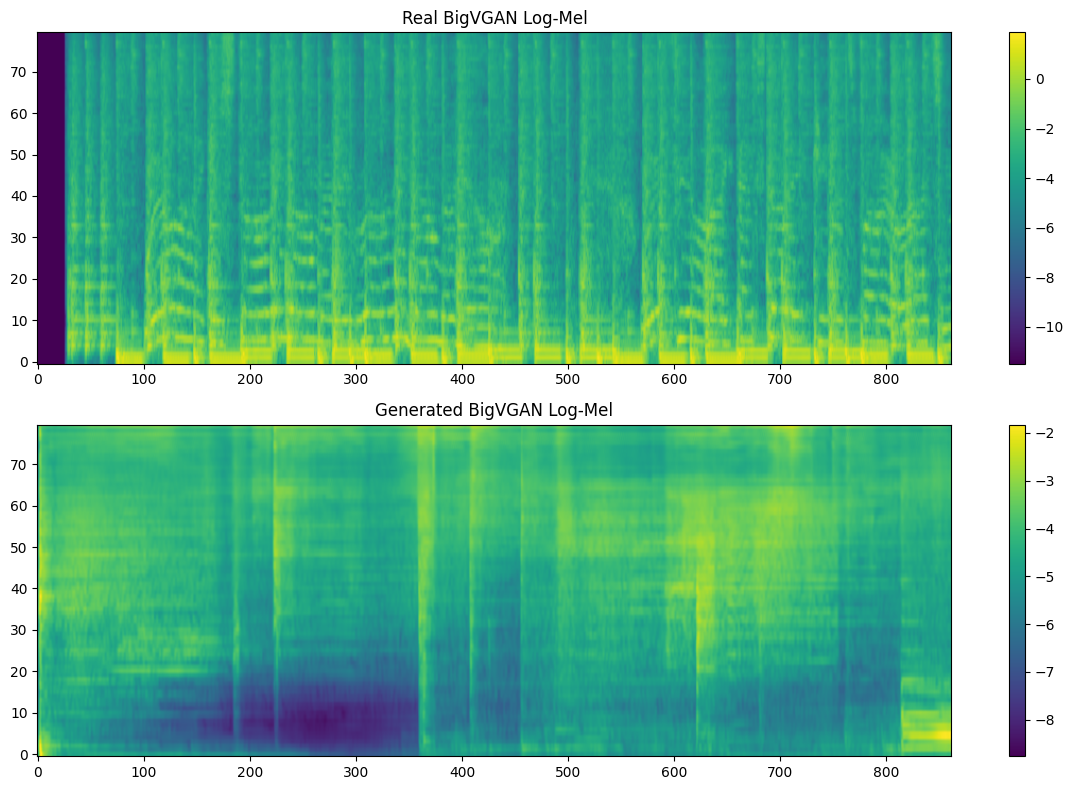

In [61]:
def print_mel_stats(name, mel):
    mel = mel.detach().cpu()

    print(f"\n{name}")
    print("shape:", mel.shape)
    print("min: ", mel.min().item())
    print("max: ", mel.max().item())
    print("mean:", mel.mean().item())
    print("std: ", mel.std().item())


# 1. get one real sample
idx = 6

real_mel_norm, real_caption = dataset[idx]
real_mel_norm = real_mel_norm.unsqueeze(0).to(device)

print("Caption:")
print(real_caption)


# 2. denormalize to BigVGAN log-mel range
real_logmel = denorm_for_bigvgan(real_mel_norm)

generated_mel_norm = sample_mel_ddim_cfg(
    unet=pipeline.unet,
    clap_encoder=pipeline.clap_encoder,
    scheduler=pipeline.scheduler,
    prompt=real_caption,
    mel_shape=real_mel_norm.shape,
    device=device,
    ddim_steps=100,
    guidance_scale=1.0
)
generated_logmel = denorm_for_bigvgan(generated_mel_norm)


# 3. print statistics
print_mel_stats("Real normalized mel", real_mel_norm)
print_mel_stats("Generated normalized mel", generated_mel_norm)

print_mel_stats("Real BigVGAN log-mel", real_logmel)
print_mel_stats("Generated BigVGAN log-mel", generated_logmel)


# 4. plot comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

im0 = axes[0].imshow(
    real_logmel[0, 0].detach().cpu().numpy(),
    origin="lower",
    aspect="auto"
)
axes[0].set_title("Real BigVGAN Log-Mel")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    generated_logmel[0, 0].detach().cpu().numpy(),
    origin="lower",
    aspect="auto"
)
axes[1].set_title("Generated BigVGAN Log-Mel")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

Hopeful Emotional Pop Ballad with Piano violin and minimal drums Repeating melody that builds into an electro house beat


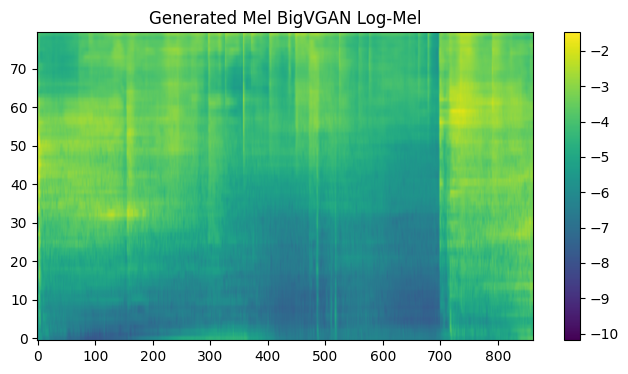

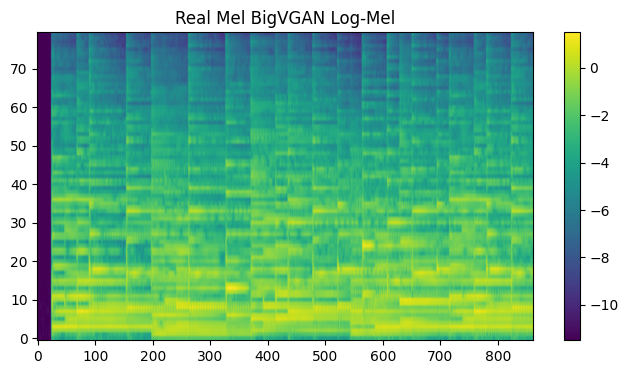

In [63]:
real_mel, real_caption = audio_dataset[77]
real_mel = real_mel.unsqueeze(0).to(device) 

print(real_caption)

generated_mel_norm = sample_mel_ddim_cfg(
    unet=pipeline.unet,
    clap_encoder=pipeline.clap_encoder,
    scheduler=pipeline.scheduler,
    prompt=real_caption,
    mel_shape=real_mel_norm.shape,
    device=device,
    ddim_steps=100,
    guidance_scale=1.0
)


gen_mel = denorm_for_bigvgan(generated_mel_norm)
real_mel = denorm_for_bigvgan(real_mel)
plt.figure(figsize=(8, 4))
plt.imshow(gen_mel[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
plt.title("Generated Mel BigVGAN Log-Mel")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 4))
plt.imshow(
    real_mel[0, 0].detach().cpu().numpy(),
    aspect="auto",
    origin="lower"
)
plt.title("Real Mel BigVGAN Log-Mel")
plt.colorbar()
plt.show()

with torch.no_grad():
    gen_audio = vocoder(gen_mel[:, 0, :, :])
    real_audio = vocoder(real_logmel[:, 0, :, :])
    
real_audio = real_audio.squeeze().detach().cpu()
gen_audio = gen_audio.squeeze().detach().cpu()
display(Audio(gen_audio.numpy(), rate=22050))
display(Audio(real_audio.numpy(), rate=22050))

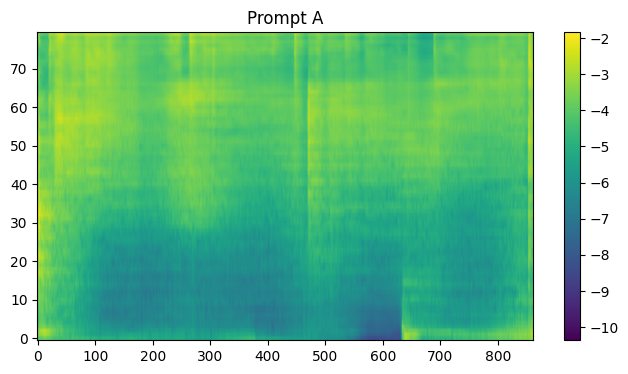

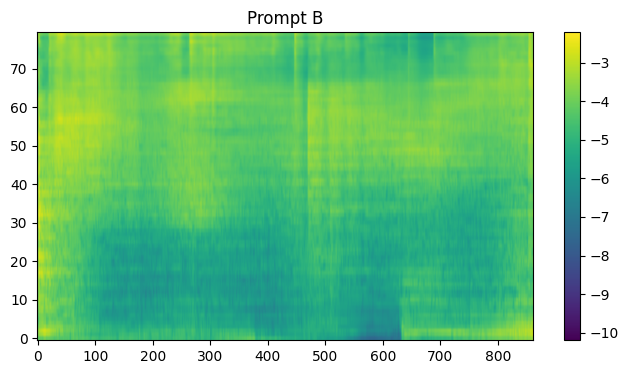

In [66]:
import random


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 尽量保证 deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed = 1234

set_seed(seed)
mel_a = sample_mel_ddim_cfg(
    unet=unet,
    clap_encoder=clap_encoder,
    scheduler=scheduler,
    prompt="a calm piano melody",
    mel_shape=mel[:1].shape,
    device=device,
    ddim_steps=100,
    guidance_scale=1.0
)

set_seed(seed)
mel_b = sample_mel_ddim_cfg(
    unet=unet,
    clap_encoder=clap_encoder,
    scheduler=scheduler,
    prompt="fast heavy metal drums and guitar",
    mel_shape=mel[:1].shape,
    device=device,
    ddim_steps=100,
    guidance_scale=1.0
)


gen_a = denorm_for_bigvgan(mel_a)
gen_b = denorm_for_bigvgan(mel_b)

plt.figure(figsize=(8, 4))
plt.imshow(gen_a[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
plt.title("Prompt A")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 4))
plt.imshow(gen_b[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
plt.title("Prompt B")
plt.colorbar()
plt.show()

In [68]:
diff = torch.mean(torch.abs(mel_a - mel_b)).item()
print("Mean abs diff:", diff)

print("mel_a range:", mel_a.min().item(), mel_a.max().item())
print("mel_b range:", mel_b.min().item(), mel_b.max().item())

Mean abs diff: 0.04030507430434227
mel_a range: -0.8319419622421265 0.4313071668148041
mel_b range: -0.8068715929985046 0.37563276290893555


## Comapre generated music to real music

In [13]:
import torch
import matplotlib.pyplot as plt
from IPython.display import Audio, display


def denorm_for_bigvgan(mel_norm):
    """
    Convert normalized mel [-1, 1] back to BigVGAN log-mel range.
    """
    mel_norm = mel_norm.clamp(-1, 1)
    mel = (mel_norm + 1) / 2 * 13.5 - 11.5
    return mel


def compare_mel_and_audio(
    real_mel_norm,
    gen_mel_norm,
    vocoder,
    sample_rate=22050,
    device="cuda"
):
    # ---------- denormalize ----------
    real_mel = denorm_for_bigvgan(real_mel_norm)
    gen_mel = denorm_for_bigvgan(gen_mel_norm)

    print("real_mel_norm:", real_mel_norm.shape)
    print("gen_mel_norm:", gen_mel_norm.shape)
    print("real_mel for vocoder:", real_mel[:, 0].shape)
    print("gen_mel for vocoder:", gen_mel[:, 0].shape)

    # ---------- plot normalized ----------
    plt.figure(figsize=(15, 9))

    plt.subplot(3, 1, 1)
    plt.imshow(real_mel_norm[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
    plt.title("Real Mel Normalized")
    plt.colorbar()

    plt.subplot(3, 1, 2)
    plt.imshow(gen_mel_norm[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
    plt.title("Generated Mel Normalized")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    # ---------- plot denormalized ----------
    plt.figure(figsize=(15, 9))

    plt.subplot(3, 1, 1)
    plt.imshow(real_mel[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
    plt.title("Real Mel BigVGAN Log-Mel")
    plt.colorbar()

    plt.subplot(3, 1, 2)
    plt.imshow(gen_mel[0, 0].detach().cpu().numpy(), aspect="auto", origin="lower")
    plt.title("Generated Mel BigVGAN Log-Mel")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    # ---------- metrics ----------
    mse = ((gen_mel_norm - real_mel_norm) ** 2).mean().item()
    mae = (gen_mel_norm - real_mel_norm).abs().mean().item()

    print("Normalized MSE:", mse)
    print("Normalized MAE:", mae)

    print("Real mel stats:")
    print(real_mel.min().item(), real_mel.max().item(), real_mel.mean().item(), real_mel.std().item())

    print("Generated mel stats:")
    print(gen_mel.min().item(), gen_mel.max().item(), gen_mel.mean().item(), gen_mel.std().item())

    # ---------- vocoder ----------
    vocoder.eval()

    with torch.no_grad():
        real_audio = vocoder(real_mel[:, 0, :, :])
        gen_audio = vocoder(gen_mel[:, 0, :, :])

    real_audio = real_audio.squeeze().detach().cpu()
    gen_audio = gen_audio.squeeze().detach().cpu()

    print("Real Audio")
    display(Audio(real_audio.numpy(), rate=sample_rate))

    print("Generated Audio")
    display(Audio(gen_audio.numpy(), rate=sample_rate))

    return real_audio, gen_audio

real_mel_norm: torch.Size([1, 1, 80, 862])
gen_mel_norm: torch.Size([1, 1, 80, 862])
real_mel for vocoder: torch.Size([1, 80, 862])
gen_mel for vocoder: torch.Size([1, 80, 862])


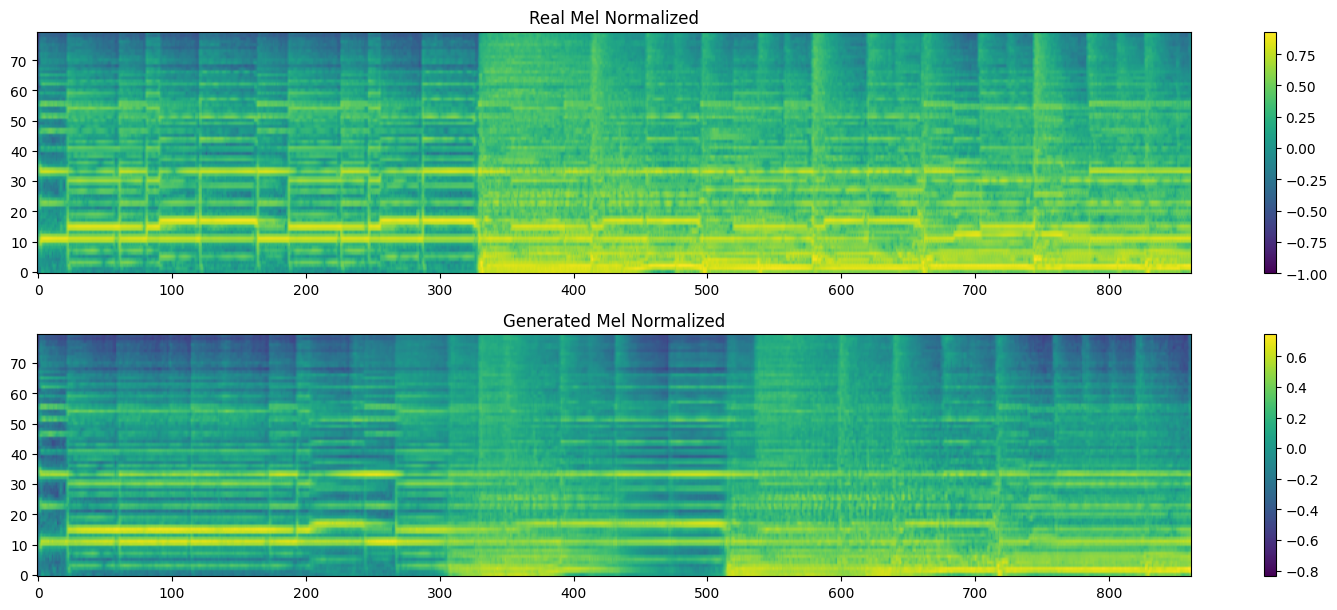

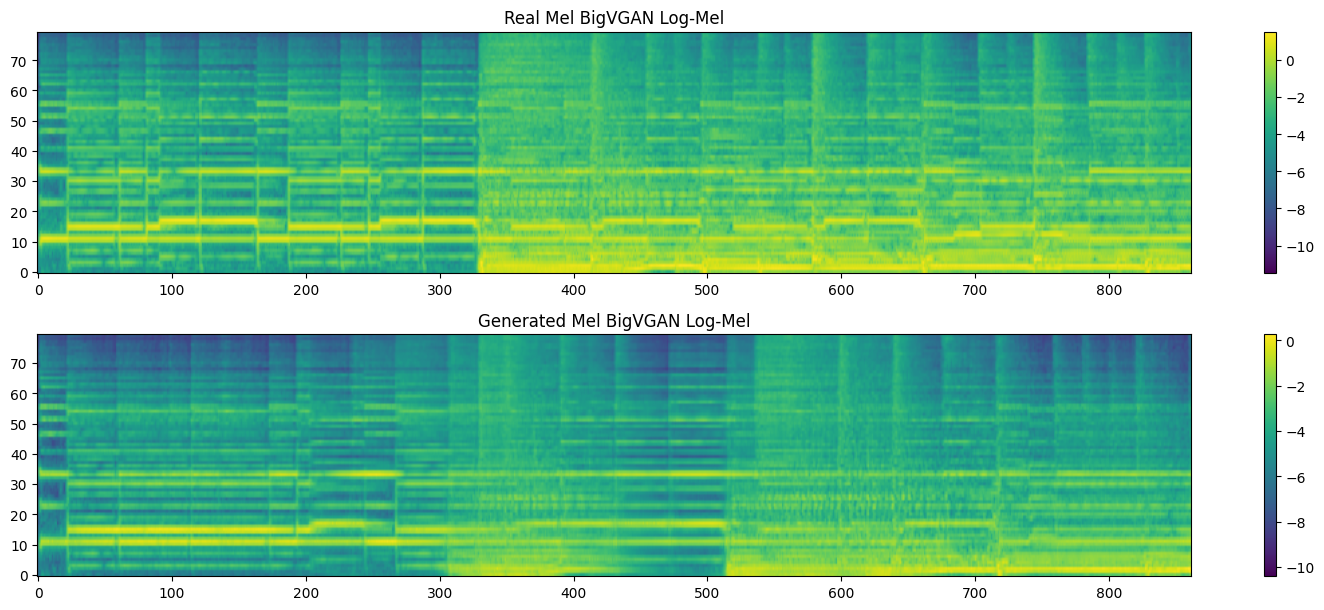

Normalized MSE: 0.06268513202667236
Normalized MAE: 0.21140535175800323
Real mel stats:
-11.5 1.5342178344726562 -2.8135440349578857 1.737979531288147
Generated mel stats:
-10.401397705078125 0.2647991180419922 -4.047386646270752 1.531186580657959
Real Audio


Generated Audio


In [43]:
%matplotlib inline

real_audio, gen_audio = compare_mel_and_audio(
    real_mel_norm=mel[2:3],
    gen_mel_norm=generated_mel_norm,
    vocoder=vocoder,
    sample_rate=22050
)